In [1]:
from google.colab import drive
import gzip
import random
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/AM


In [2]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

In [3]:
import networkx as nx
import random

# Create the graph from sampled edges
G = nx.DiGraph()
G.add_edges_from(sample_edges)

def run_sir_simulation(G, seed_nodes, beta=0.3, gamma=0.1, max_steps=50):
    states = {node: 'S' for node in G.nodes()}
    for seed in seed_nodes:
        states[seed] = 'I'

    history = []
    for t in range(max_steps):
        counts = Counter(states.values())
        history.append({'step': t, 'S': counts['S'], 'I': counts['I'], 'R': counts['R']})

        if counts['I'] == 0:
            break

        new_states = states.copy()
        for u in G.nodes():
            if states[u] == 'I':
                # Infect neighbors
                for v in G.neighbors(u):
                    if states[v] == 'S' and random.random() < beta:
                        new_states[v] = 'I'
                # Recover
                if random.random() < gamma:
                    new_states[u] = 'R'
        states = new_states
    return history

In [4]:
# Scenario 1: Random Seed
random_seed = [random.choice(list(G.nodes()))]
history_random = run_sir_simulation(G, random_seed)

# Scenario 2: Central Seed (Highest Out-Degree)
degree_cent = nx.out_degree_centrality(G)
central_seed = [max(degree_cent, key=degree_cent.get)]
history_central = run_sir_simulation(G, central_seed)

print(f"Random seed node: {random_seed[0]}")
print(f"Central seed node: {central_seed[0]} (Degree: {G.out_degree(central_seed[0])})")

Random seed node: 809494
Central seed node: 226798 (Degree: 71)


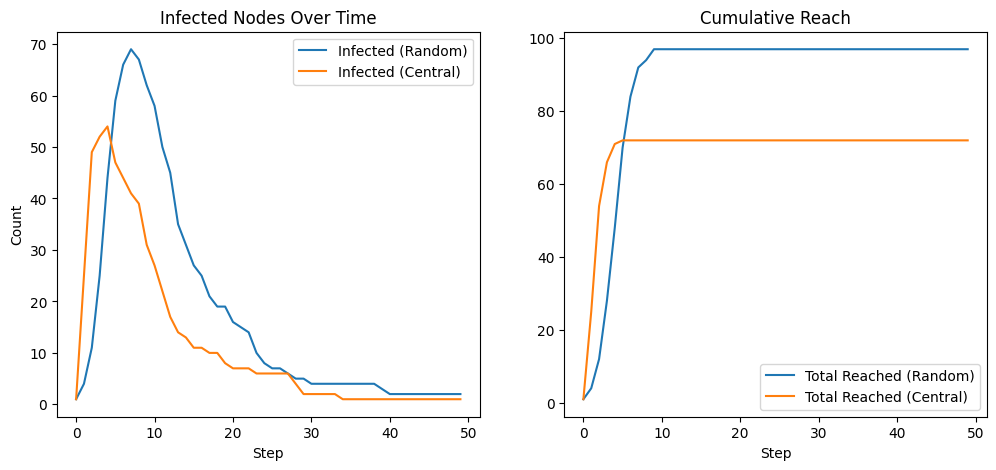

In [5]:
def plot_comparison(h1, h2, label1, label2):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot([step['I'] for step in h1], label=f'Infected ({label1})')
    plt.plot([step['I'] for step in h2], label=f'Infected ({label2})')
    plt.title('Infected Nodes Over Time')
    plt.xlabel('Step')
    plt.ylabel('Count')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot([step['R'] + step['I'] for step in h1], label=f'Total Reached ({label1})')
    plt.plot([step['R'] + step['I'] for step in h2], label=f'Total Reached ({label2})')
    plt.title('Cumulative Reach')
    plt.xlabel('Step')
    plt.legend()
    plt.show()

plot_comparison(history_random, history_central, "Random", "Central")